In [3]:
from scipy.fft import fft, fftfreq, fftshift , ifft , ifftshift
import numpy as np
import matplotlib.pyplot as plt
#import cupy as cp


In [1]:
import numpy as np
np.arange(0.0, 0.1, 0.01)

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09])

/home/sh3rawy/Documents/exit-tutorial-hell/acoustic-camera-DIY/software/.myenv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sh3rawy/Documents/exit-tutorial-hell/acoustic-camera-DIY/software/.myenv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(1000.0, 5000.0)

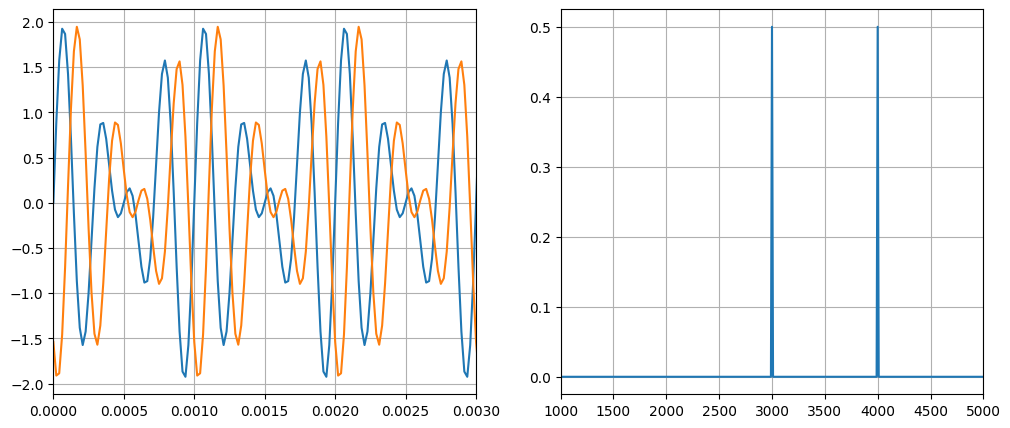

In [4]:
# num of samples 
N = 4800
T = 1 / 48000
t = np.arange(0.0 , N*T , T)
S = np.sin(2* np.pi * 4000 * t) + np.sin(2* np.pi * 3000 * t) 

tf = fftfreq(N,T)
tf = fftshift(tf)
Sf = fft(S)
Sf = fftshift(Sf)

Sf = Sf * np.exp(-1j * 2* np.pi * tf * .0001)



S_sh = ifft(ifftshift(Sf))


fig , axes = plt.subplots(1,2, figsize = (12,5))
axes[0].plot(t,S)
axes[0].plot(t,S_sh)
axes[0].grid()
axes[0].set_xlim(0,0.003)

axes[1].plot(tf , 1.0/N * np.abs(Sf))
axes[1].grid()
axes[1].set_xlim(1000,5000)

In [5]:
fftfreq(N,T)

array([  0.,  10.,  20., ..., -30., -20., -10.], shape=(4800,))

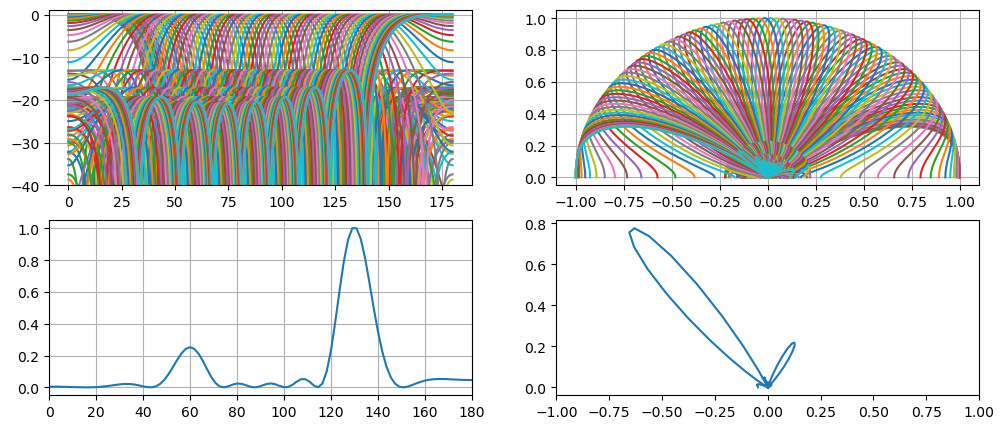

In [72]:
Nc = 6
c = 343
l = c/4000
d = 0.034
k = 2*np.pi*4000 / c
theta = np.linspace(0, np.pi, 2000)
mic = np.arange(1,12)-Nc
steering_angles = np.deg2rad(np.linspace(0, 180, 100))

W = np.exp ( -1j*k*d * np.outer(mic , np.cos(steering_angles)))
V =  np.exp(-1j*k*d * np.outer (mic , np.cos(theta)))

B = np.abs(W.conj().T @ V)
B = B / np.max(B, axis=1, keepdims=True)
Bdb = 20*np.log10(B + 1e-12)



# testing signal 
N = 4800
T = 1 / 48000
t = np.arange(0.0 , N*T , T)

# source 1
S1 = np.sin(2* np.pi * 1000 * t)
Sf1 = fftshift(fft(S1))
theta_src1 = np.deg2rad(60)
# source steering vector
a = np.exp(-1j * k * d *mic * np.cos(theta_src1))
signal1 = a[:, None] * Sf1[None, :]

# source 2
S2 = 2*np.sin(2* np.pi * 4000 * t)
Sf2 = fftshift(fft(S2))
theta_src2 = np.deg2rad(130)
# source steering vector
a = np.exp(-1j * k * d *mic * np.cos(theta_src2))
signal2 = a[:, None] * Sf2[None, :]

# source 3
S3 = np.sin(2* np.pi * 4000 * t)
Sf3 = fftshift(fft(S3))
theta_src3 = np.deg2rad(30)
# source steering vector
a = np.exp(-1j * k * d *mic * np.cos(theta_src3))
signal3 = a[:, None] * Sf3[None, :]


signal = signal1 + signal2


Y = np.abs(W.conj().T @ signal)
# beam power
P = np.mean(np.abs(Y)**2, axis=1)
# normalize
P = P / np.max(P)

xp = P * np.cos(steering_angles)
yp = P * np.sin(steering_angles)

# plot
fig , axes = plt.subplots(2,2, figsize = (12,5))

for i, ang in enumerate(steering_angles):
    axes[0][0].plot(
        np.rad2deg(theta),
        Bdb[i],
    )

for i in range(B.shape[0]):
    x = B[i] * np.cos(theta)
    y = B[i] * np.sin(theta)
    axes[0][1].plot(x,y)

axes[1][0].plot(np.rad2deg(steering_angles),P)
axes[1][1].plot(xp,yp)

axes[1][0].set_xlim(0,180)
axes[1][1].set_xlim(-1,1)
axes[0][0].set_ylim(-40,1)



axes[0][0].grid()
axes[0][1].grid()
axes[1][0].grid()


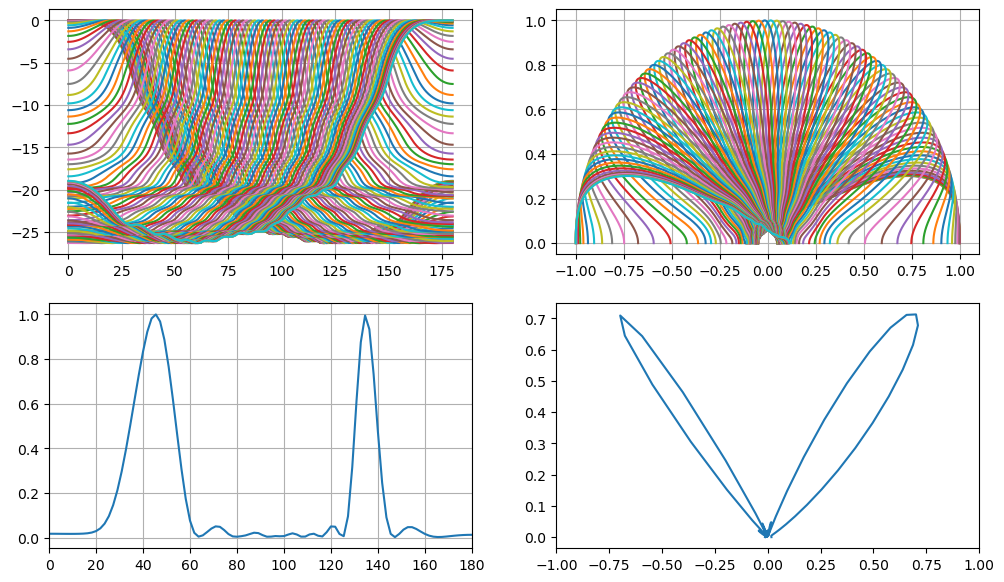

In [ ]:
Nc = 8
c = 343
l = c/4000
d = l/2
k = 2*np.pi / c * np.linspace(1000,4001,100)

theta = np.linspace(0, np.pi, 2000)
mic = np.arange(1,16)-Nc
steering_angles = np.deg2rad(np.linspace(0, 180, 100))


# steering matrix
W = np.exp(-1j * d * k[:, None, None] * mic[None, :, None] * np.cos(steering_angles[None, None, :]))

# response matrix
V = np.exp(-1j * d * k[:, None, None] * mic[None, :, None] * np.cos(theta[None, None, :]))




# beamforming
B_freq_domain = np.einsum('fms, fma -> fsa', W.conj(), V)
# wideband combine
B = np.mean(np.abs(B_freq_domain), axis=0)

# 5. Normalize and dB
# Result B is (SteeringAngles, ScanAngles)
B = B / np.max(B, axis=1, keepdims=True)
Bdb = 20 * np.log10(B + 1e-12)



# # testing signal 
N = 4800
T = 1 / 48000
t = np.arange(0.0 , N*T , T)
tf = fftshift(fftfreq(N,T))
k2 = np.array([2000,3000,4000])

# source 1
S1 = np.sin(2* np.pi * 4000 * t)
Sf1 = fftshift(fft(S1))
theta_src1 = np.deg2rad(60)
# source steering vector
a = np.exp(-1j * d * np.cos(theta_src1) * 4000 * mic)
signal1 = np.outer(a , Sf1)

# source 2
S2 = np.sin(2* np.pi * 2000 * t)
Sf2 = fftshift(fft(S2))
theta_src2 = np.deg2rad(120)
# source steering vector
a = np.exp(-1j * d * np.cos(theta_src2) * 2000 * mic)
signal2 = np.outer(a , Sf2)

signal = signal1 + signal2


idx_list = [np.argmin(np.abs(tf - (ki * c / (2 * np.pi)))) for ki in k]


signal_aligned = signal.T[idx_list, :] 

Y = np.einsum('fms, fm -> fs', W.conj(), signal_aligned)
# # beam power
P = np.mean(np.abs(Y)**2, axis=0)
# # normalize
P = P / np.max(P)


xp = P * np.cos(steering_angles)
yp = P * np.sin(steering_angles)

# plot
fig , axes = plt.subplots(2,2, figsize = (12,7))

for i, ang in enumerate(steering_angles):
    axes[0][0].plot(
        np.rad2deg(theta),
        Bdb[i],
    )

for i in range(B.shape[0]):
    x = B[i] * np.cos(theta)
    y = B[i] * np.sin(theta)
    axes[0][1].plot(x,y)

axes[1][0].plot(np.rad2deg(steering_angles),P)
axes[1][1].plot(xp,yp)
# 
axes[1][0].set_xlim(0,180)
axes[1][1].set_xlim(-1,1)



axes[0][0].grid()
axes[0][1].grid()
axes[1][0].grid()


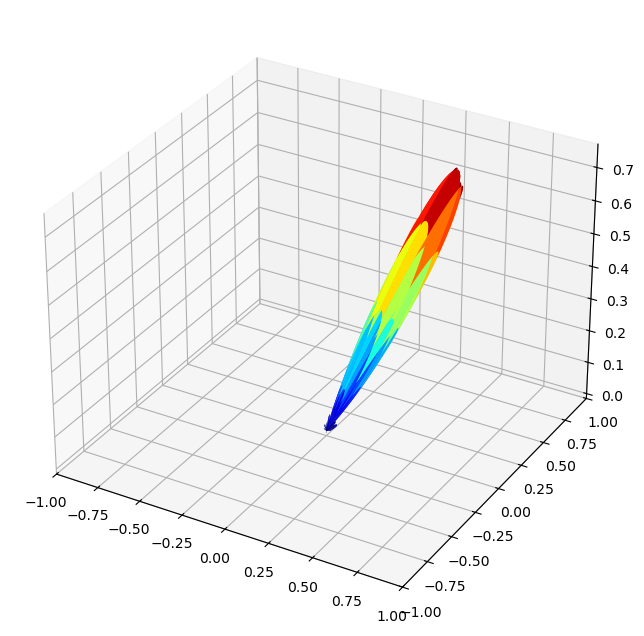

In [31]:


c = 343
f = 4000

lam = c / f
d = lam / 2
k = 2 * np.pi / lam

# ARRAY GEOMETRY
Ncx = 4
Ncy = 4
micx = np.arange(7) - Ncx + 1
micy = np.arange(7) - Ncy + 1
micx, micy = np.meshgrid(micx, micy)
# Flatten sensors
micx = micx.flatten()
micy = micy.flatten()

# ANGLE GRID
theta = np.linspace(0, np.pi, 300)
phi   = np.linspace(0, np.pi, 300)
theta, phi = np.meshgrid(theta, phi)

# Flatten angle grid
theta_flat = theta.flatten()
phi_flat = phi.flatten()

# STEERING MATRIX

V = np.exp(
    -1j * k * d *
    (
        micx[:, None] * np.cos(theta_flat)[None, :] +
        micy[:, None] * np.cos(phi_flat)[None, :]
    )
)

# BEAM STEERING DIRECTION

theta0 = np.deg2rad(60)
phi0 = np.deg2rad(60)

W = np.exp(
    -1j * k * d *
    (
        micx * np.cos(theta0) +
        micy * np.cos(phi0)
    )
)

# CONVENTIONAL BEAMFORMER

B = np.abs(W.conj() @ V) ** 2

# reshape back to angle grid
B = B.reshape(theta.shape)

B_norm = B / np.max(B)

R = B_norm 

X = R * np.cos(theta) 
Y = R * np.cos(phi)
Z = R * np.sin(theta) * np.sin(phi)
# ux = np.cos(theta)
# uy = np.cos(phi)

# valid = ux**2 + uy**2 <= 1

# uz = np.zeros_like(ux)
# uz[valid] = np.sqrt(1 - ux[valid]**2 - uy[valid]**2)

# X = R * ux
# Y = R * uy
# Z = R * uz

# PLOT

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap='jet',
    linewidth=0,
    antialiased=True
)

plt.show()

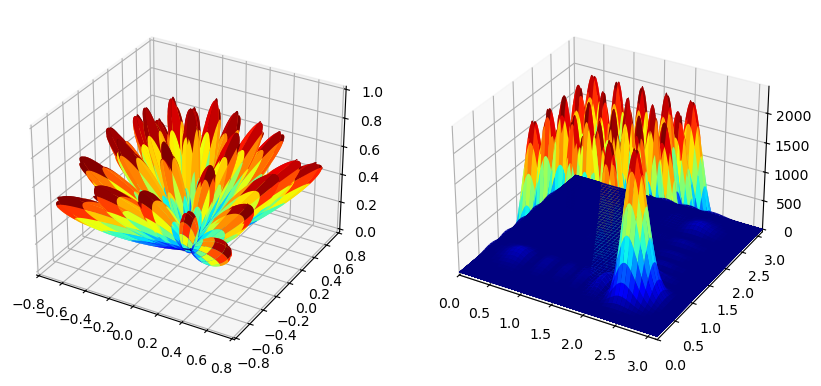

In [46]:

from scipy.fft import fft, fftfreq, fftshift, ifft, ifftshift
import numpy as np
import matplotlib.pyplot as plt

c = 343
f = 4000

lam = c / f
d = lam / 2
k = 2 * np.pi / lam

# ARRAY GEOMETRY
Ncx = 4
Ncy = 4
micx = np.arange(7) - Ncx + 1
micy = np.arange(7) - Ncy + 1
micx, micy = np.meshgrid(micx, micy)
# Flatten sensors
micx = micx.flatten()
micy = micy.flatten()

# ANGLE GRID
theta = np.linspace(0, np.pi, 300)
phi   = np.linspace(0, np.pi, 300)
theta, phi = np.meshgrid(theta, phi)


# Flatten angle grid
theta_flat = theta.flatten()
phi_flat = phi.flatten()


# steering grid 
steer_theta = np.linspace(np.deg2rad(45), np.deg2rad(135), 5)
steer_phi   = np.linspace(np.deg2rad(45), np.deg2rad(135), 5)
steer_theta, steer_phi = np.meshgrid(steer_theta, steer_phi)

# Flatten angle grid
steer_theta_flat = steer_theta.flatten()
steer_phi_flat = steer_phi.flatten()


# STEERING MATRIX

V = np.exp(
    -1j * k * d *
    (
        micx[:, None] * np.cos(theta_flat)[None, :] +
        micy[:, None] * np.cos(phi_flat)[None, :]
    )
)

# BEAM STEERING DIRECTION

theta0 = np.deg2rad(90)
phi0 = np.deg2rad(60)

W = np.exp(
    -1j * k * d *
    (
        micx[:, None] * np.cos(steer_theta_flat)[None, :] +
        micy[:, None] * np.cos(steer_phi_flat)[None, :]
    )
)

# CONVENTIONAL BEAMFORMER

B_raw = np.abs(W.conj().T @ V)**2

# 2. RESHAPE TO: (Number of Beams, Theta Res, Phi Res)
# This maps each of the 25 beams to the 300x300 plotting grid
B = B_raw.reshape(len(steer_theta_flat), theta.shape[0], theta.shape[1])




fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# 3. LOOP THROUGH EACH STEERED BEAM
for i in range(B.shape[0]):
    Bi = B[i] 
    R = Bi / np.max(Bi)
    
    X = R * np.cos(theta) 
    Y = R * np.cos(phi)
    Z = R * np.sin(theta) * np.sin(phi)
    
    ax1.plot_surface(
        X, Y, Z,
        cmap='jet'
        # linewidth=0
    )
    
    ax2.plot_surface(
        theta,phi,Bi,
        cmap='jet'
        # linewidth=0
        )

# ax.set_xlim(-1,1)
# ax.set_ylim(-1,1)

ax2.set_xlim(0,np.deg2rad(180))
ax2.set_ylim(0,np.deg2rad(180))

# ax.set_title(f"Radiation Patterns for {len(steer_theta_flat)} Beams")
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
plt.show()




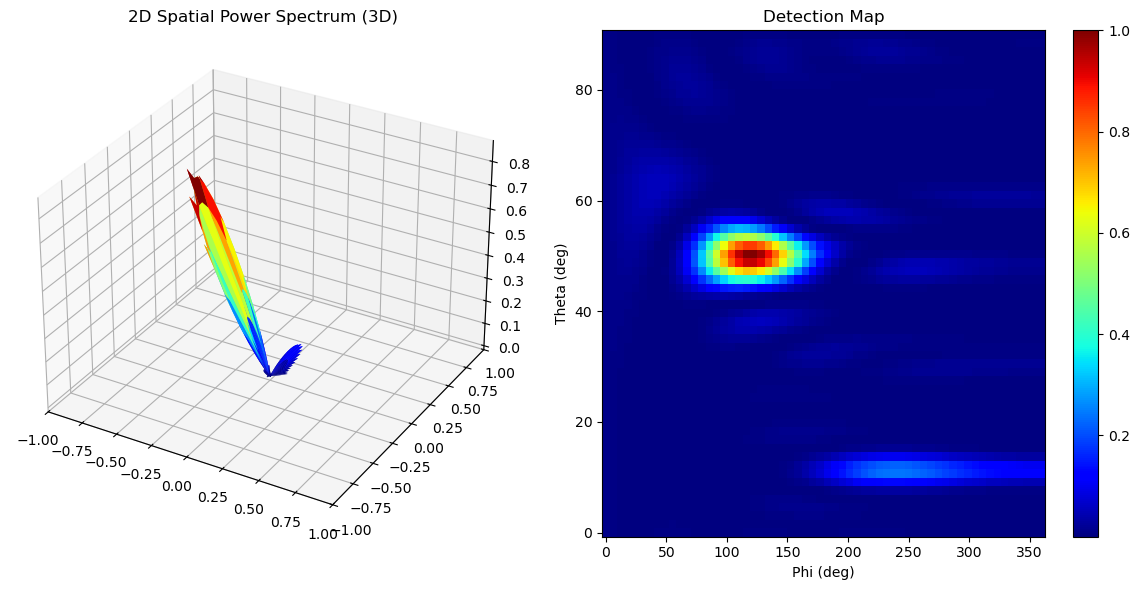

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift

c = 343
f_signal = 4000
lam = c / f_signal
d = lam / 2
k = 2 * np.pi * f_signal / c

Ncx, Ncy = 4, 4
mx = np.arange(7) - Ncx + 1
my = np.arange(7) - Ncy + 1
micx, micy = np.meshgrid(mx, my)
micx, micy = micx.flatten(), micy.flatten()

# STEERING GRID
res = 60
s_theta = np.linspace(0, np.pi/2, res)  # 0 to 90 degrees
s_phi = np.linspace(0, 2*np.pi, res)    # 0 to 360 degrees
steer_theta, steer_phi = np.meshgrid(s_theta, s_phi)

# Steering Matrix W
W = np.exp(
    1j * k * d * (
        micx[:, None] * (np.sin(steer_theta) * np.cos(steer_phi)).flatten()[None, :] +
        micy[:, None] * (np.sin(steer_theta) * np.sin(steer_phi)).flatten()[None, :]
    )
)

# GENERATE TEST SIGNALS
fs = 48000
T = 1/fs
t = np.arange(0, 4800*T, T)

# Source 1: 60 deg theta, 45 deg phi
st1, sp1 = np.deg2rad(60), np.deg2rad(45)
Sf1 = fftshift(fft(np.sin(2 * np.pi * 1000 * t)))
a1 = np.exp(1j * k * d * (micx * np.sin(st1) * np.cos(sp1) + micy * np.sin(st1) * np.sin(sp1)))
sig1 = a1[:, None] * Sf1[None, :]

# Source 2: 30 deg theta, 200 deg phi
st2, sp2 = np.deg2rad(30), np.deg2rad(200)
Sf2 = fftshift(fft(2 * np.sin(2 * np.pi * 4000 * t)))
a2 = np.exp(1j * k * d * (micx * np.sin(st2) * np.cos(sp2) + micy * np.sin(st2) * np.sin(sp2)))
sig2 = a2[:, None] * Sf2[None, :]

signal = sig1 + sig2

Y = W.conj().T @ signal

P = np.mean(np.abs(Y)**2, axis=1)

P_grid = P.reshape(steer_theta.shape)
P_norm = P_grid / np.max(P_grid)

R = P_norm
X = R * np.sin(steer_theta) * np.cos(steer_phi)
Y_p = R * np.sin(steer_theta) * np.sin(steer_phi)
Z = R * np.cos(steer_theta)

fig = plt.figure(figsize=(12, 6))

# 3D Spatial Power Map
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y_p, Z, cmap='jet', antialiased=True)
ax1.set_title("2D Spatial Power Spectrum (3D)")
ax1.set_xlim(-1,1)
ax1.set_ylim(-1,1)

# 2D Heatmap of Steering Angles
ax2 = fig.add_subplot(122)
im = ax2.pcolormesh(np.rad2deg(s_phi), np.rad2deg(s_theta), P_norm, shading='auto', cmap='jet')
ax2.set_xlabel("Phi (deg)")
ax2.set_ylabel("Theta (deg)")
ax2.set_title("Detection Map")
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()